In [1]:
import pickle
import warnings
warnings.filterwarnings("ignore")

import pandas as pd

from sklearn.model_selection import train_test_split

# Classification models
from sklearn.linear_model import LogisticRegression as c_lm
from sklearn.neighbors import KNeighborsClassifier as c_knn
from sklearn.tree import DecisionTreeClassifier as c_dt
from sklearn.ensemble import RandomForestClassifier as c_rf, GradientBoostingClassifier as c_gbf
from sklearn.svm import SVC as c_svm
from sklearn.neural_network import MLPClassifier as c_mlp

# Hyperparam tuning
from sklearn.model_selection import GridSearchCV

# Model evaluation
from ml_pipeline.model_evaluation import evaluate_classification

In [2]:
# Import data, perform SAME (match random state) train/test split
path = "./data/supply_chain.csv"
data = pd.read_csv(path)

# Split target from data
target = 'received_on_time'

# Drop records w/o target (can't train if no target)
data.dropna(subset = [target], inplace=True)

# Drop duplicates
data.drop_duplicates(inplace=True)

# Separate target from the rest of the data
cols = list(data.columns)
cols.remove(target)

# Define dependent and independent variables
y = data[target]
X = data[cols]

# Immediately train test split
# ! THE RANDOM SEED MUST MATCH WHAT YOU DID DURING DATA PREP!!!
x_tr, x_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

In [3]:
# Import pickle and transform data
with open("./pickles/data_pipeline.pickle", 'rb') as handle:
    pipe = pickle.load(handle)
    x_tr = pipe.transform(x_tr)
    x_te = pipe.transform(x_te)

x_tr.head()

,lead_time,price,units_ordered,ln(phone_calls_placed),ln(total_order),material_low_lead,material_abz582,material_ayy404,mgmt_escalated_n,ordered_inside_lead_time_n,...,req_date_month_12,req_date_month_6,req_date_month_9,req_date_month_5,req_date_month_8,req_date_month_7,req_date_month_4,req_date_month_2,req_date_month_10,req_date_month_11
541,2.0,18.18,161.0,2.197225,8.003991,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
440,17.0,316.07,75.0,2.397895,10.076228,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0
482,3.0,36.99,72.0,2.772589,7.911756,1,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
422,1.0,21.20,66.0,2.484907,6.282566,1,0,0,1,1,...,0,0,0,0,0,0,1,0,0,0
778,3.0,36.99,152.0,3.135494,8.646181,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


### Modelling (Usually, you'd build several models, do some hyperparametric tuning, etc.)

In [4]:
# Instantiate    
    # Hyperparameters:
        # n_estimators: integer
        # max_depth: integer
gbf_model = c_gbf(n_estimators = 50, max_depth = 2)

# Train the model 
gbf_model.fit(x_tr, y_tr)

# Generate Predictions
gbf_tr = gbf_model.predict(x_tr)
gbf_te = gbf_model.predict(x_te)

### Evaluate

In [5]:
# Evaluate
metrics, blindcm, traincm, testcm = evaluate_classification(y_tr, gbf_tr, y_te, gbf_te)
metrics

,metric,base,train,test
0,Accuracy,0.7286,0.9343,0.8733
1,Precision,0.7286,0.9444,0.9031
2,Recall,1.0000,0.9667,0.9276
3,F1,0.8430,0.9554,0.9152


In [6]:
# Training set confusion matrix
traincm.confusion_matrix

pred,N,Y
truth,,
N,161,29
Y,17,493


In [7]:
traincm.confusion_matrix_rel

pred,N,Y
truth,,
N,0.2300,0.0414
Y,0.0243,0.7043


In [8]:
# Test Set confusion matrix
testcm.confusion_matrix_rel

pred,N,Y
truth,,
N,0.1900,0.0733
Y,0.0533,0.6833


<Axes: xlabel='importance', ylabel='variable'>

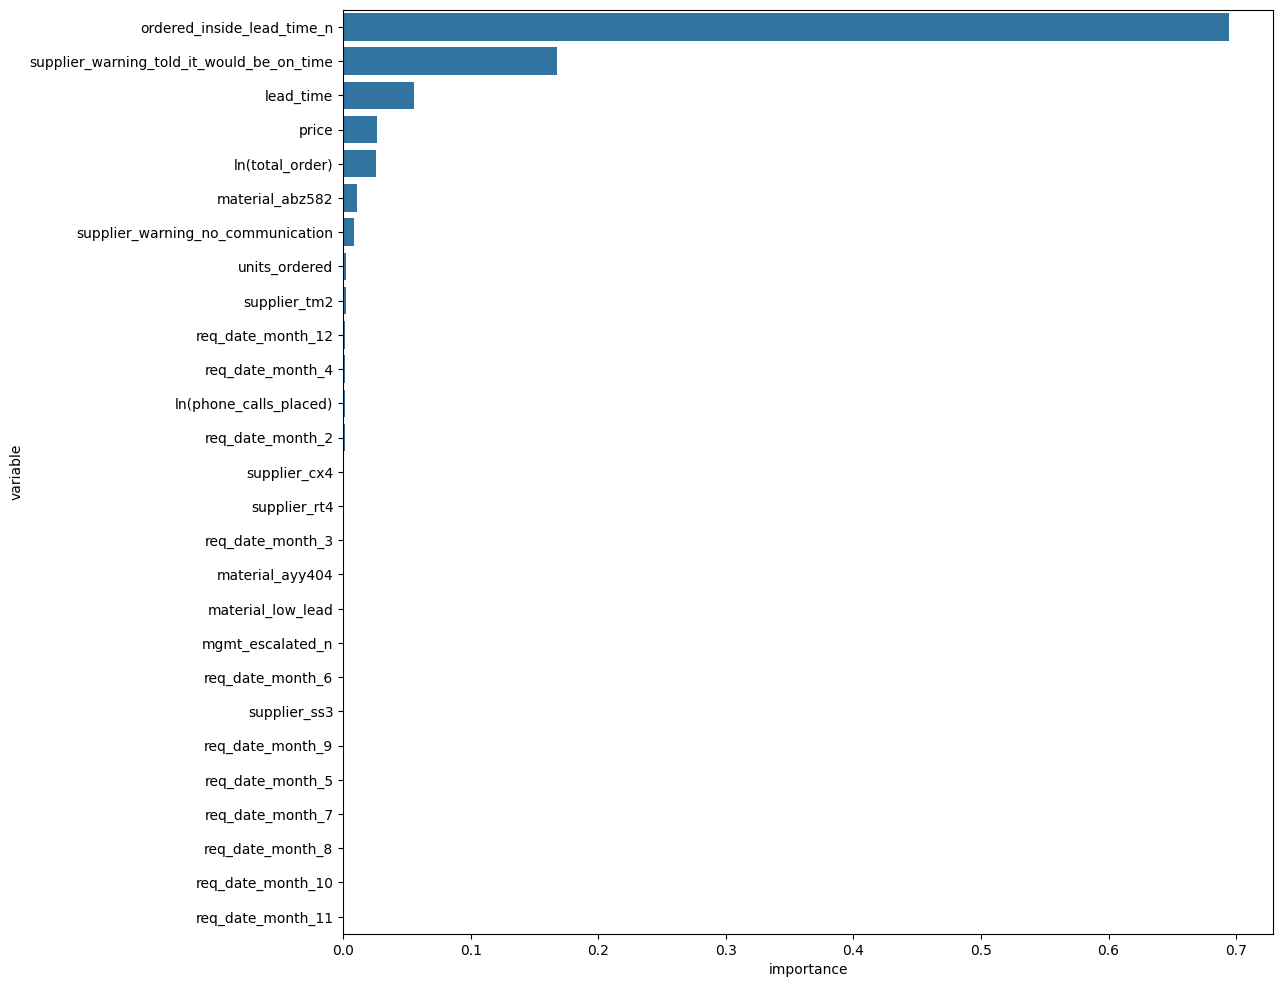

In [9]:
# Special ability if using random forest or gradient boosted forest

import matplotlib.pyplot as plt
import seaborn as sns

lbl = list(gbf_model.feature_names_in_)
imp = list(gbf_model.feature_importances_)
impdf = pd.DataFrame({'variable':lbl,'importance':imp})
impdf.sort_values('importance', ascending=False, inplace=True)

fig = plt.figure(figsize = (12,12))
sns.barplot(x=impdf['importance'], y=impdf['variable'])

### Finalize model (train on ENTIRE data set, save the model as a pickle)

In [10]:
# Concatenate full data set (we do this to train the ML model on ALL our data so it has more data to learn from)
X = pd.concat([x_tr, x_te], axis = 0, ignore_index = True)
y = pd.concat([y_tr, y_te], axis = 0, ignore_index = True)

# We use the same exact hyperparameters from tuning
gbf_model = c_gbf(n_estimators = 50, max_depth = 2)

# Train the model 
gbf_model.fit(X, y)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",50
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",2
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, `

In [11]:
# Pickle and save the model
with open("./pickles/supply_chain_classifier.pickle", 'wb') as handle:
    pickle.dump(gbf_model, handle)